# Actividad 1: Preprocesamiento ágil
**Asignatura:** Gestión de Proyectos de Inteligencia de Negocio | **Fecha:** Abril 2026

---
Este notebook analiza el dataset `matriculas_gradoposgrado.xlsx` del Ministerio de Universidades español (cursos 2015/16 a 2021/22), con el objetivo de proporcionar a la dirección del grupo educativo la información necesaria para tomar decisiones estratégicas sobre la apertura de una nueva universidad en España.

## Importación de librerías y carga de datos

In [18]:
import pandas as pd
import numpy as np

# Carga de las dos pestañas del Excel
df_grado  = pd.read_excel('matriculas_gradoposgrado.xlsx', sheet_name='Matriculados Grado')
df_master = pd.read_excel('matriculas_gradoposgrado.xlsx', sheet_name='Matriculados Master')

print(f'Grado  → {df_grado.shape[0]:,} filas, {df_grado.shape[1]} columnas')
print(f'Máster → {df_master.shape[0]:,} filas, {df_master.shape[1]} columnas')
df_grado.head(3)

Grado  → 4,235 filas, 18 columnas
Máster → 5,292 filas, 18 columnas


,Comunidad autónoma,Universidad,Rama,Titulación,matriculas2122,mujeres2122,matriculas2021,mujeres2021,matriculas1920,mujeres1920,matriculas1819,mujeres1819,matriculas1718,mujeres1718,matriculas1617,mujeres1617,matriculas1516,mujeres1516
0,Cataluña,Abat Oliba CEU,Ciencias Sociales y Jurídicas,Graduado o Graduada en Ciencias Políticas por ...,43,0.488372,28,0.571429,33,0.454545,29,0.310345,,,,,,
1,Cataluña,Abat Oliba CEU,Ciencias Sociales y Jurídicas,Graduado o Graduada en Criminología y Segurida...,146,0.636986,135,0.696296,116,0.698276,110,0.681818,40,0.4,43,0.325581,44,0.25
2,Cataluña,Abat Oliba CEU,Ciencias Sociales y Jurídicas,Graduado o Graduada en Derecho por la Universi...,324,0.512346,285,0.533333,250,0.54,266,0.533835,220,0.531818,197,0.548223,186,0.516129


**1. ¿De qué tipo de variables se compone la base de datos? Realiza dos tablas resumen (una para Grado y otra para Máster) en la que se observe, por universidad, el máximo, el mínimo, la media y la desviación típica del número de alumnos matriculados y del porcentaje de mujeres en sus estudios en el curso 21/22. Describe brevemente los hallazgos más relevantes tras este conocimiento inicial.**



In [19]:
# ¿Qué tipo de variables tiene el dataset?
print('=== TIPOS DE VARIABLES INICIALES - GRADO ===')
print(df_grado.dtypes)

=== TIPOS DE VARIABLES INICIALES - GRADO ===
Comunidad autónoma    object
Universidad           object
Rama                  object
Titulación            object
matriculas2122        object
mujeres2122           object
matriculas2021        object
mujeres2021           object
matriculas1920        object
mujeres1920           object
matriculas1819        object
mujeres1819           object
matriculas1718        object
mujeres1718           object
matriculas1617        object
mujeres1617           object
matriculas1516        object
mujeres1516           object
dtype: object


Todas las columnas son tipo texto. Vamos a transformarlas para que las variables numéricas sean de tipo numérico (Los puntos marcan decimales por lo quue no tenemos que preocuparnos de eso)

In [20]:
# Columnas numéricas: matrículas y porcentaje de mujeres por curso
mat_cols = ['matriculas2122','matriculas2021','matriculas1920','matriculas1819',
            'matriculas1718','matriculas1617','matriculas1516']
muj_cols = ['mujeres2122','mujeres2021','mujeres1920','mujeres1819',
            'mujeres1718','mujeres1617','mujeres1516']

def limpiar_df(df):
    """Convierte a numérico todas las columnas de matrículas y porcentajes."""
    for col in mat_cols + muj_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_grado  = limpiar_df(df_grado)
df_master = limpiar_df(df_master)

# Comprobación: ¿cuántos nulos por columna?
print('Nulos en Grado:')
print(df_grado[mat_cols + muj_cols].isnull().sum())
print('\nNulos en Máster:')
print(df_master[mat_cols + muj_cols].isnull().sum())

Nulos en Grado:
matriculas2122    305
matriculas2021    358
matriculas1920    451
matriculas1819    574
matriculas1718    700
matriculas1617    829
matriculas1516    951
mujeres2122       384
mujeres2021       422
mujeres1920       505
mujeres1819       638
mujeres1718       755
mujeres1617       880
mujeres1516       991
dtype: int64

Nulos en Máster:
matriculas2122    1248
matriculas2021    1332
matriculas1920    1392
matriculas1819    1425
matriculas1718    1504
matriculas1617    1519
matriculas1516    1542
mujeres2122       1334
mujeres2021       1426
mujeres1920       1497
mujeres1819       1556
mujeres1718       1616
mujeres1617       1666
mujeres1516       1725
dtype: int64


In [21]:
# ¿Qué tipo de variables tiene ahora el dataset?
print('=== TIPOS DE VARIABLES MODIFICADO - GRADO ===')
print(df_grado.dtypes)

=== TIPOS DE VARIABLES MODIFICADO - GRADO ===
Comunidad autónoma     object
Universidad            object
Rama                   object
Titulación             object
matriculas2122        float64
mujeres2122           float64
matriculas2021        float64
mujeres2021           float64
matriculas1920        float64
mujeres1920           float64
matriculas1819        float64
mujeres1819           float64
matriculas1718        float64
mujeres1718           float64
matriculas1617        float64
mujeres1617           float64
matriculas1516        float64
mujeres1516           float64
dtype: object


Ahora las variables Comunidad Autonoma, Universidad, Rama y titulación son variables tipo texto y el resto son tipo float

Para cada universidad calculamos el **máximo**, **mínimo**, **media** y **desviación típica** del número de alumnos matriculados (`matriculas2122`) y del porcentaje de mujeres (`mujeres2122`) en el curso 2021/22.

Usamos `groupby().agg()`.

In [22]:
# 1. Tabla resumen para GRADO
tabla_grado = df_grado.groupby('Universidad').agg({
    'matriculas2122': ['max', 'min', 'mean', 'std'],
    'mujeres2122': ['max', 'min', 'mean', 'std']
}).round(2)

print("=== Tabla descriptiva – Grado (curso 21/22) ===")
print(tabla_grado)

# 2. Tabla resumen para MÁSTER
tabla_master = df_master.groupby('Universidad').agg({
    'matriculas2122': ['max', 'min', 'mean', 'std'],
    'mujeres2122': ['max', 'min', 'mean', 'std']
}).round(2)

#Importamos función para ver todas las filas
import pandas as pd

pd.set_option('display.max_rows', None)

print("\n=== Tabla descriptiva – Máster (curso 21/22) ===")
print(tabla_master)

=== Tabla descriptiva – Grado (curso 21/22) ===
                                         matriculas2122                  \
                                                    max    min     mean   
Universidad                                                               
A Coruña                                         1307.0   10.0   250.94   
A Distancia de Madrid                             579.0    1.0   195.76   
Abat Oliba CEU                                    418.0   42.0   153.33   
Alcalá                                           1085.0    1.0   320.51   
Alfonso X El Sabio                               1512.0    1.0   134.22   
Alicante                                         1711.0   12.0   444.65   
Almería                                           854.0   33.0   323.03   
Antonio de Nebrija                                764.0    1.0    73.31   
Atlántico Medio                                   631.0   13.0   163.25   
Autónoma de Barcelona                            221

In [23]:
# Ordenamos la tabla de Grado por la media de alumnos de mayor a menor
top_medias_grado = tabla_grado.sort_values(by=('matriculas2122', 'mean'), ascending=False)

print("=== GRADO: Universidades con mayor media de alumnos por titulación ===")
print(top_medias_grado[[('matriculas2122', 'max'), ('matriculas2122', 'mean'), ('matriculas2122', 'std'), ('mujeres2122', 'max'), ('mujeres2122', 'mean'), ('mujeres2122', 'std')]].head(10))


=== GRADO: Universidades con mayor media de alumnos por titulación ===
                                  matriculas2122                    \
                                             max     mean      std   
Universidad                                                          
Nacional de Educación a Distancia        31077.0  4765.89  6166.06   
Oberta de Catalunya                       6813.0  1928.88  1922.62   
Internacional de La Rioja                 4539.0   777.59  1199.46   
Complutense de Madrid                     4205.0   603.20   659.78   
València (Estudi General)                 2618.0   583.37   579.08   
Sevilla                                   2993.0   576.11   586.13   
Granada                                   3426.0   563.90   587.11   
Barcelona                                 3527.0   491.33   591.70   
Politécnica de Madrid                     2801.0   460.34   564.92   
Málaga                                    1678.0   446.54   343.93   

                  

**Grado:**
* **Escalabilidad masiva en el modelo a distancia:** Las universidades online o a distancia (UNED, UOC y UNIR) lideran  el volumen de alumnos. El caso de la UNED es extremo: alcanza picos de 31.077 alumnos en un solo grado y una media de 4.765. Sin embargo, su desviación típica (6.166) es incluso superior a su media, lo que indica una altísima polarización: unas pocas "titulaciones estrella" masificadas sostienen el volumen, mientras conviven con multitud de grados minoritarios.
* **El "techo" logístico de la educación presencial:** Las grandes universidades tradicionales (Complutense, Sevilla, València, Granada) muestran una barrera física evidente. Sus medias de matriculación caen drásticamente a la franja de los 450-600 alumnos por titulación. Aunque logran picos de demanda respetables (como los 4.205 alumnos de la Complutense), quedan muy lejos de los volúmenes del formato a distancia, demostrando al grupo educativo que el crecimiento sin límites de infraestructura está en el modelo online.
* **Brecha de género y el factor STEM:** El análisis de la presencia femenina (mujeres2122) revela patrones de segmentación claros. Las universidades generalistas alcanzan medias en torno al 58-61% (Complutense, Barcelona, València) con nichos específicos que rozan el 97% de mujeres. En el extremo opuesto, la Politécnica de Madrid visibiliza la fuerte brecha de género en las ingenierías y ramas técnicas, desplomándose a una media de solo el 35% de alumnado femenino.


In [24]:
# Ordenamos la tabla de Máster por el máximo de alumnos matriculados
top_maximos_master = tabla_master.sort_values(by=('matriculas2122', 'max'), ascending=False)

print("\n=== MÁSTER: Universidades con mayor pico de alumnos en una titulación ===")
print(top_maximos_master[[('matriculas2122', 'max'), ('matriculas2122', 'mean'), ('matriculas2122', 'std'),('mujeres2122', 'max'), ('mujeres2122', 'mean'), ('mujeres2122', 'std')]].head(10))


=== MÁSTER: Universidades con mayor pico de alumnos en una titulación ===
                                   matriculas2122                 mujeres2122  \
                                              max    mean     std         max   
Universidad                                                                     
Internacional Valenciana                   2673.0  270.00  401.68        0.75   
Oberta de Catalunya                        1794.0  398.19  374.41        0.91   
Internacional de La Rioja                  1659.0  233.72  290.88        1.00   
Nacional de Educación a Distancia          1216.0  136.51  190.37        0.92   
València (Estudi General)                  1200.0   56.24  119.90        1.00   
Internacional Isabel I de Castilla         1145.0  104.75  279.97        0.90   
Politécnica de Catalunya                   1100.0   70.59  138.22        1.00   
Alfonso X El Sabio                         1088.0  103.23  219.25        1.00   
Católica San Antonio              


**Máster:**


*  **Escalabilidad y "Titulaciones Estrella" en el modelo online**: Las universidades a distancia (VIU, UOC, UNIR y UNED) dominan los picos de matriculación, destacando la VIU con un máster masivo de 2.673 alumnos. Sin embargo, la enorme desviación típica observada en estas instituciones (ej. VIU: media de 270 frente a una desviación de 401) revela un modelo de "titulaciones estrella": unos pocos posgrados absorben una demanda gigantesca, mientras conviven con multitud de másteres "nicho" con muy pocos alumnos.

*  **El límite logístico de la presencialidad**: Universidades tradicionales como la Universitat de València o la Politécnica de Catalunya (UPC) logran picos superiores a los 1.100 alumnos en programas concretos, pero su media general se desploma hasta los 56 y 70 alumnos, respectivamente. Esto evidencia la barrera física (limitación de aulas, horarios y profesorado) que sufre la educación presencial frente a la flexibilidad del formato online.

*  **Brecha de género y nichos de mercado:** El análisis de la presencia femenina (mujeres2122) muestra extremos muy valiosos para marketing. Por un lado, existen nichos de mercado 100% femeninos (máximos del 100% en varias universidades). Por otro lado, la UPC visibiliza la brecha de género en el sector STEM: mientras el resto de instituciones promedian entre un 49% y 60% de mujeres, esta universidad técnica cae a una media de solo el 35%.

**2. Haz representaciones gráficas para Grado, y otra para Máster, en la que se observe el top 30 de universidades españolas con más alumnos en los 7 cursos que incluye el dataset. ¿Existe consonancia entre el top 30 de Grados y Máster?**


Para identificar las universidades con mayor masa estudiantil, sumamos las matrículas de los **7 cursos** disponibles. Así obtenemos una medida más robusta y menos sensible a un año atípico.

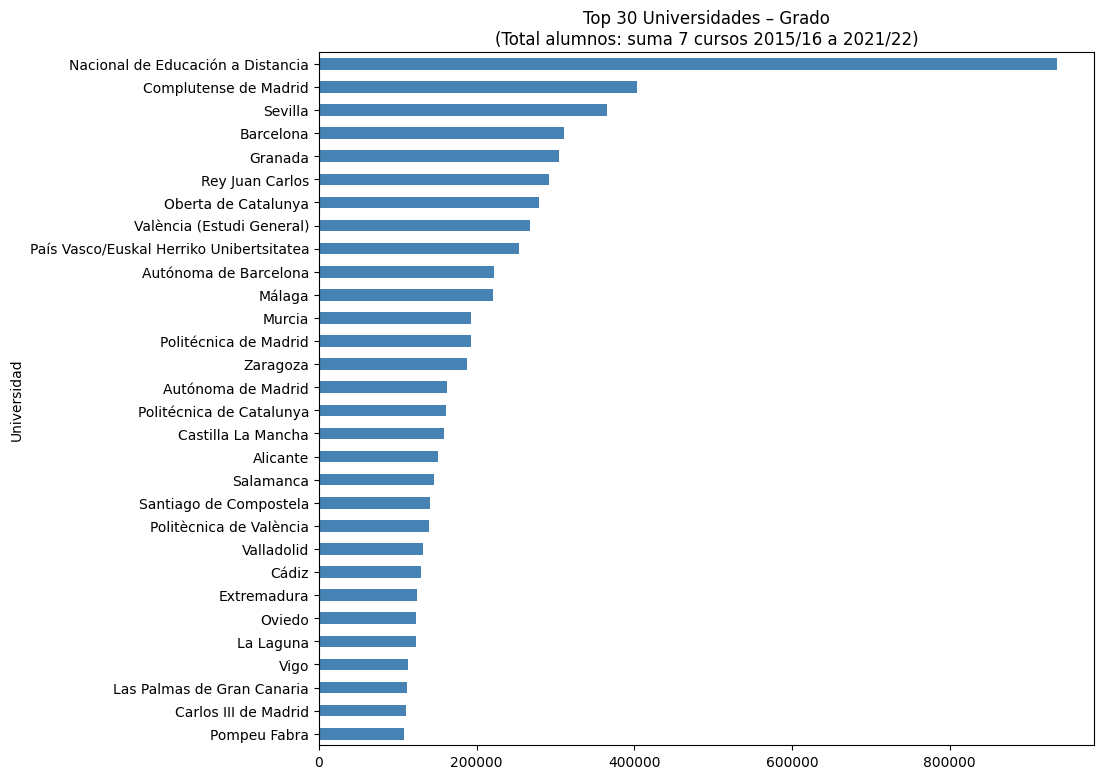

In [25]:
mat_cols = ['matriculas2122', 'matriculas2021', 'matriculas1920', 'matriculas1819', 'matriculas1718', 'matriculas1617', 'matriculas1516']

def top30_universidades(df, nombre, color):
    df2 = df.copy()

    # Sumamos los 7 cursos por titulación
    df2['total_7'] = df2[mat_cols].sum(axis=1)

    # Agrupamos por universidad, cogemos las 30 con más alumnos y ordenamos de menor a mayor
    top = df2.groupby('Universidad')['total_7'].sum().nlargest(30).sort_values(ascending=True)

    # Dibujamos directamente usando la función integrada de Pandas (.plot.barh)
    top.plot.barh(
        title=f'Top 30 Universidades – {nombre}\n(Total alumnos: suma 7 cursos 2015/16 a 2021/22)',
        color=color,
        figsize=(10, 9)
    )

    return top

# Ejecutamos la función
top_grado  = top30_universidades(df_grado,  'Grado',  'steelblue')



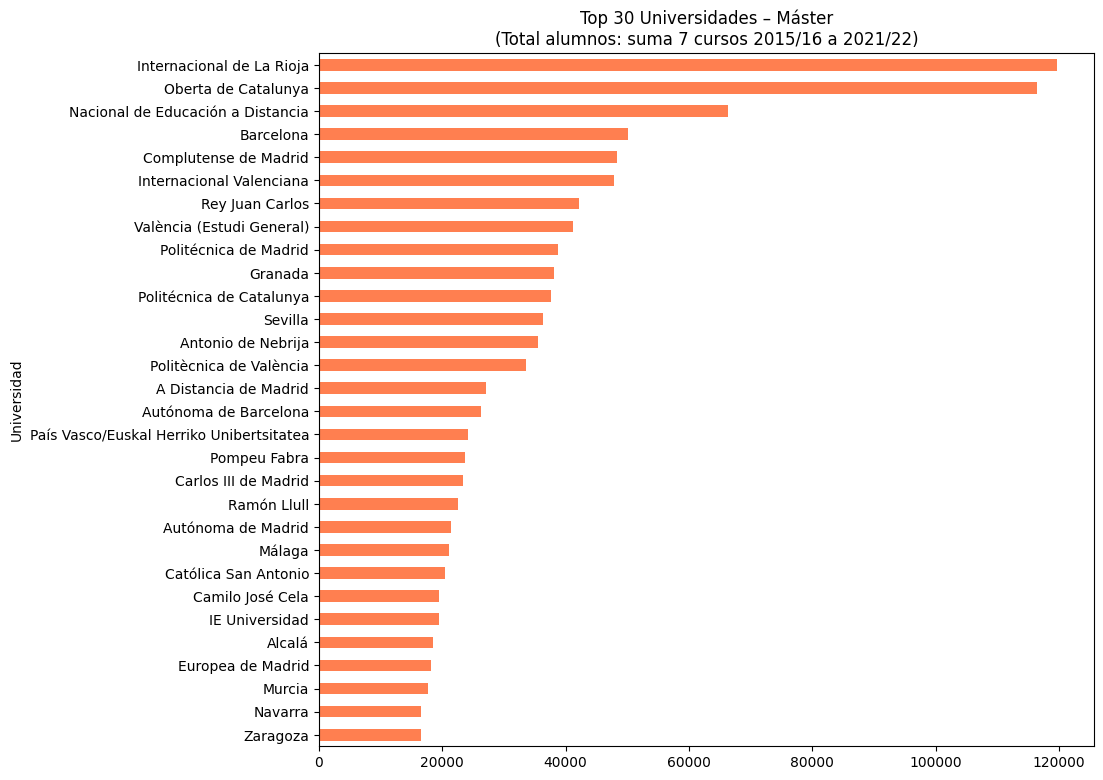

In [26]:
top_master = top30_universidades(df_master, 'Máster', 'coral')

In [27]:
# ¿Cuántas universidades coinciden en ambos top30?
comunes = set(top_grado.index) & set(top_master.index)
print(f'Universidades presentes en AMBOS top30: {len(comunes)}')
print(sorted(comunes))
print(f'\nUniversidades SOLO en Grado: {set(top_grado.index) - comunes}')
print(f'Universidades SOLO en Máster: {set(top_master.index) - comunes}')

Universidades presentes en AMBOS top30: 19
['Autónoma de Barcelona', 'Autónoma de Madrid', 'Barcelona', 'Carlos III de Madrid', 'Complutense de Madrid', 'Granada', 'Murcia', 'Málaga', 'Nacional de Educación a Distancia', 'Oberta de Catalunya', 'País Vasco/Euskal Herriko Unibertsitatea', 'Politècnica de València', 'Politécnica de Catalunya', 'Politécnica de Madrid', 'Pompeu Fabra', 'Rey Juan Carlos', 'Sevilla', 'València (Estudi General)', 'Zaragoza']

Universidades SOLO en Grado: {'Extremadura', 'Alicante', 'Salamanca', 'Las Palmas de Gran Canaria', 'Oviedo', 'Santiago de Compostela', 'Vigo', 'Cádiz', 'Castilla La Mancha', 'Valladolid', 'La Laguna'}
Universidades SOLO en Máster: {'Alcalá', 'IE Universidad', 'A Distancia de Madrid', 'Internacional Valenciana', 'Camilo José Cela', 'Internacional de La Rioja', 'Europea de Madrid', 'Ramón Llull', 'Navarra', 'Antonio de Nebrija', 'Católica San Antonio'}


Existe **consonancia parcial** entre ambos rankings: **19 de las 30 universidades** coinciden en los dos top30.

Las grandes universidades presenciales tradicionales (Complutense, Sevilla, Granada, Barcelona, Autónoma de Madrid/Barcelona) están en el top en ambos rankings, lo que refleja una oferta consolidada tanto en grado como en posgrado.

Las principales diferencias son:
- **Grado**: domina la **UNED** con una ventaja enorme (>930.000 alumnos acumulados en 7 cursos), muy por encima del segundo clasificado.
- **Máster**: aparecen con fuerza universidades online como la **UNIR** y la **UOC**, que en grado tienen menor peso relativo, evidenciando que el modelo a distancia ha capturado una cuota significativa del mercado de posgrado.

Para el grupo educativo, esto sugiere que la competencia en grado presencial es diferente a la del máster online, dos mercados con dinámicas propias.

**3. La dirección general del grupo educativo está pensando en lanzar un máster de Business Analytics vinculado a la rama de conocimiento “Ciencias Sociales y Jurídicas”. Por ello, piden tablas y representaciones gráficas que permitan conocer el número de alumnos y porcentaje de mujeres en másteres de “Ciencias Sociales y Jurídicas” que contengan en su título las palabras “Inteligencia de Negocio”, “Analítica de Negocio”, “Análisis de Datos” o “Ciencia de Datos”.**

Filtramos los másteres de la rama **'Ciencias Sociales y Jurídicas'** cuyo título contenga alguna de las palabras clave: *Inteligencia de Negocio*, *Analítica de Negocio*, *Análisis de Datos* o *Ciencia de Datos*.

Usamos `str.contains()` con el parámetro `case=False` para ignorar mayúsculas/minúsculas

In [28]:
# 1. Filtramos primero por la rama de Ciencias Sociales y Jurídicas
df_csj = df_master[df_master['Rama'] == 'Ciencias Sociales y Jurídicas']

# 2. Escribimos las palabras clave en un solo texto separadas por el operador | (OR)
palabras_clave = "Inteligencia de Negocio|Analítica de Negocio|Análisis de Datos|Ciencia de Datos"

# 3. Filtramos las titulaciones que contengan esas palabras
df_kw = df_csj[df_csj['Titulación'].str.contains(palabras_clave, case=False, na=False)].copy()

# 4. Calculamos el total de alumnos de los 7 cursos, definidos antes
df_kw['total_alumnos'] = df_kw[mat_cols].sum(axis=1)

# Mostramos directamente la tabla final con las columnas que nos interesan
df_kw[['Universidad', 'Titulación', 'matriculas2122', 'mujeres2122', 'total_alumnos']]


,Universidad,Titulación,matriculas2122,mujeres2122,total_alumnos
1210,Castilla La Mancha,Máster Universitario en Modelización y Análisi...,10.0,0.100000,25.0
1437,Complutense de Madrid,Máster Universitario en Minería de Datos e Int...,69.0,0.449275,477.0
2235,IE Universidad,Máster Universitario en Analítica de Negocio y...,97.0,0.309278,704.0
2258,Illes Balears (Les),Máster Universitario en Análisis de Datos Masi...,39.0,0.230769,240.0
2413,Internacional de La Rioja,Máster Universitario en Inteligencia de Negoci...,217.0,0.414747,435.0
3419,Oviedo,Máster Universitario en Análisis de Datos para...,36.0,0.416667,152.0
4057,Pompeu Fabra,Máster Universitario en Ciencia de Datos por l...,46.0,0.326087,173.0
4217,Ramón Llull,Máster Universitario en Análisis de Datos para...,133.0,0.360902,504.0


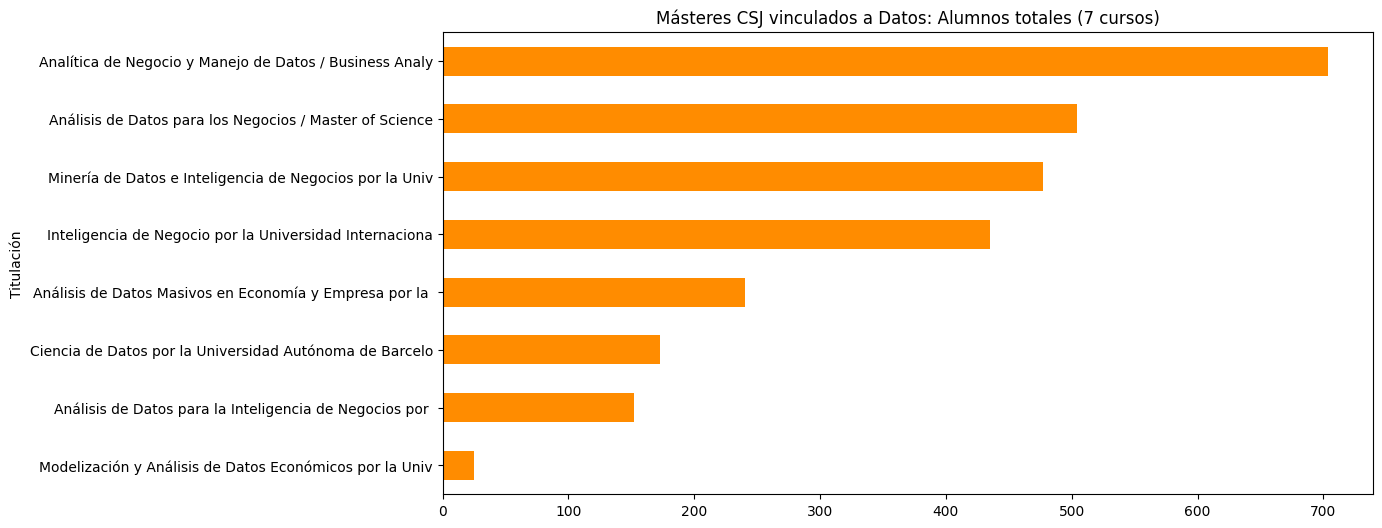

In [29]:
# 1. Ordenamos de menor a mayor por total de alumnos (Clave para que el gráfico quede de mayor a menor)
df_kw_ordenado = df_kw.sort_values(by='total_alumnos', ascending=True)

# 2. Ponemos la Titulación como índice para que Pandas la use en el eje Y del gráfico
df_kw_ordenado.set_index('Titulación', inplace=True)

# 3. Acortamos los nombres de los másteres en el índice para que se lean bien
df_kw_ordenado.index = df_kw_ordenado.index.str.replace('Máster Universitario en ', '').str[:55]

# 4. El "atajo visual" de Pandas: dibujamos directamente la columna que queremos
df_kw_ordenado['total_alumnos'].plot.barh(
    title='Másteres CSJ vinculados a Datos: Alumnos totales (7 cursos)',
    color='darkorange',
    figsize=(12, 6)
); #Pongo ; para que no salga titulo

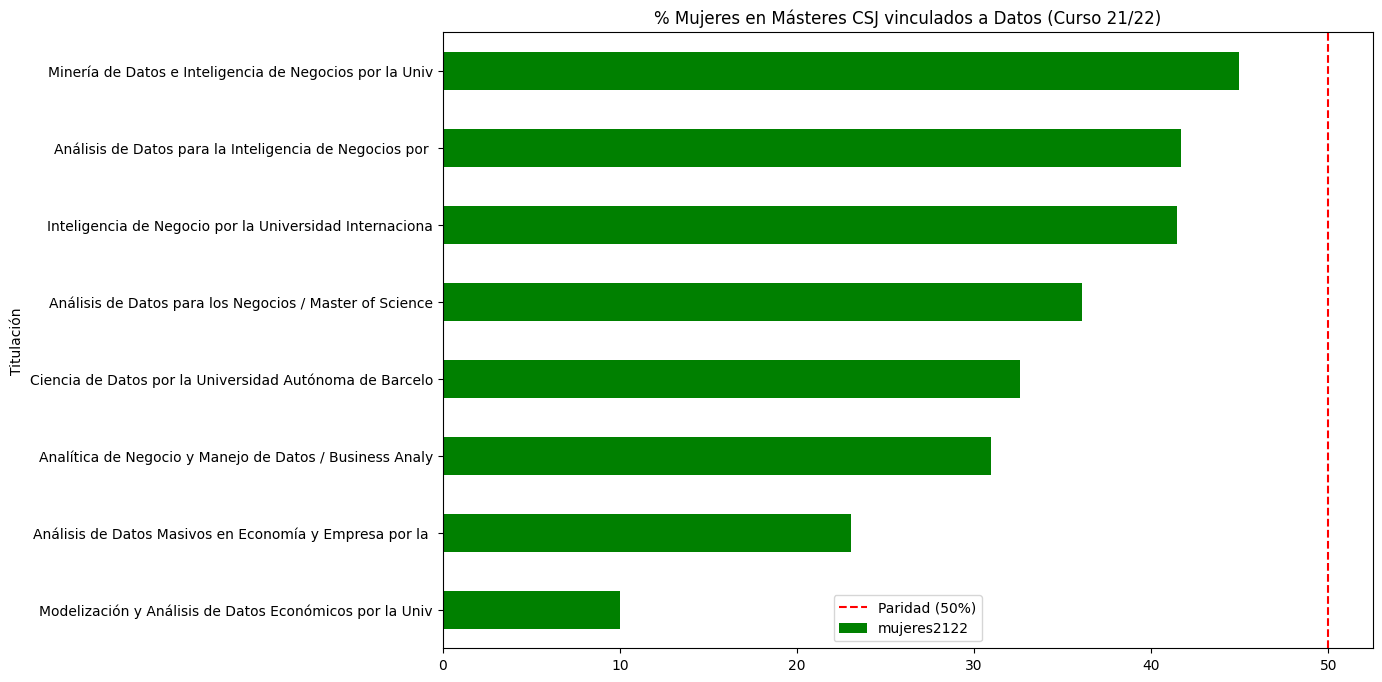

In [30]:
# 1. Usamos df_kw y filtramos los posibles valores nulos (NaN) en la columna de mujeres // Si hacen otro tratamiento, imputar por
#media, mediana también bien pero todavía no se ha explicado.
df_kw2 = df_kw.dropna(subset=['mujeres2122']).copy()

# 2. Multiplicamos por 100 para tener los porcentajes sobre 100 y no sobre 1.
df_kw2['mujeres2122'] = df_kw2['mujeres2122'] * 100

# 3. Ordenamos de menor a mayor por el porcentaje de mujeres
df_kw2_ordenado = df_kw2.sort_values(by='mujeres2122', ascending=True)

# 4. Ponemos la Titulación como índice y la limpiamos para que el gráfico sea legible
df_kw2_ordenado.set_index('Titulación', inplace=True)
df_kw2_ordenado.index = df_kw2_ordenado.index.str.replace('Máster Universitario en ', '').str.replace('Máster en ', '').str[:55]

# 5. El "atajo visual" de Pandas: dibujamos directamente desde la columna
grafico_mujeres = df_kw2_ordenado['mujeres2122'].plot.barh(
    title='% Mujeres en Másteres CSJ vinculados a Datos (Curso 21/22)',
    color='green',
    figsize=(12, 8)
)

# 6. Añadimos la línea de paridad
grafico_mujeres.axvline(50, color='red', linestyle='--', label='Paridad (50%)')
grafico_mujeres.legend();


Se han identificado **8 titulaciones de máster** en la rama de Ciencias Sociales y Jurídicas relacionadas con Inteligencia de Negocio/Analítica de Negocio/Análisis de Datos/Ciencia de Datos

Los hallazgos más relevantes son:
- El **'Máster en Analítica de Negocio y Manejo de Datos / Business Analytics'** es el más matriculado con más de 700 alumnos acumulados en 7 cursos, seguido de **'Análisis de Datos para los Negocios'** con más de 500 y **'Minería de Datos e Inteligencia de Negocios'** con unos 480.
- El **porcentaje de mujeres es generalmente bajo** en estos másteres, oscilando entre el 10% y el 45%, muy por debajo de la paridad. Esto es relevante para la campaña de marketing del grupo educativo: hay un nicho claro para atraer a más mujeres a este tipo de formación.
- La existencia de 8 titulaciones ya establecidas confirma que el mercado del máster en Business Analytics dentro de Ciencias Sociales y Jurídicas **es un mercado real con demanda creciente**, aunque con espacio para nuevos entrantes con una propuesta diferenciadora.

**4. Finalmente, el grupo educativo quiere lanzar una campaña de marketing en redes sociales para publicitar los estudios que lanzará. Para ello, quiere conocer el top 30 de titulaciones con más presencia de mujeres. Además, la dirección general quiere conocer si la presencia de mujeres por “Rama de Conocimiento” ha sufrido cambios en los últimos 7 cursos.**


Top 30 de titulaciones con más presencia de mujeres:

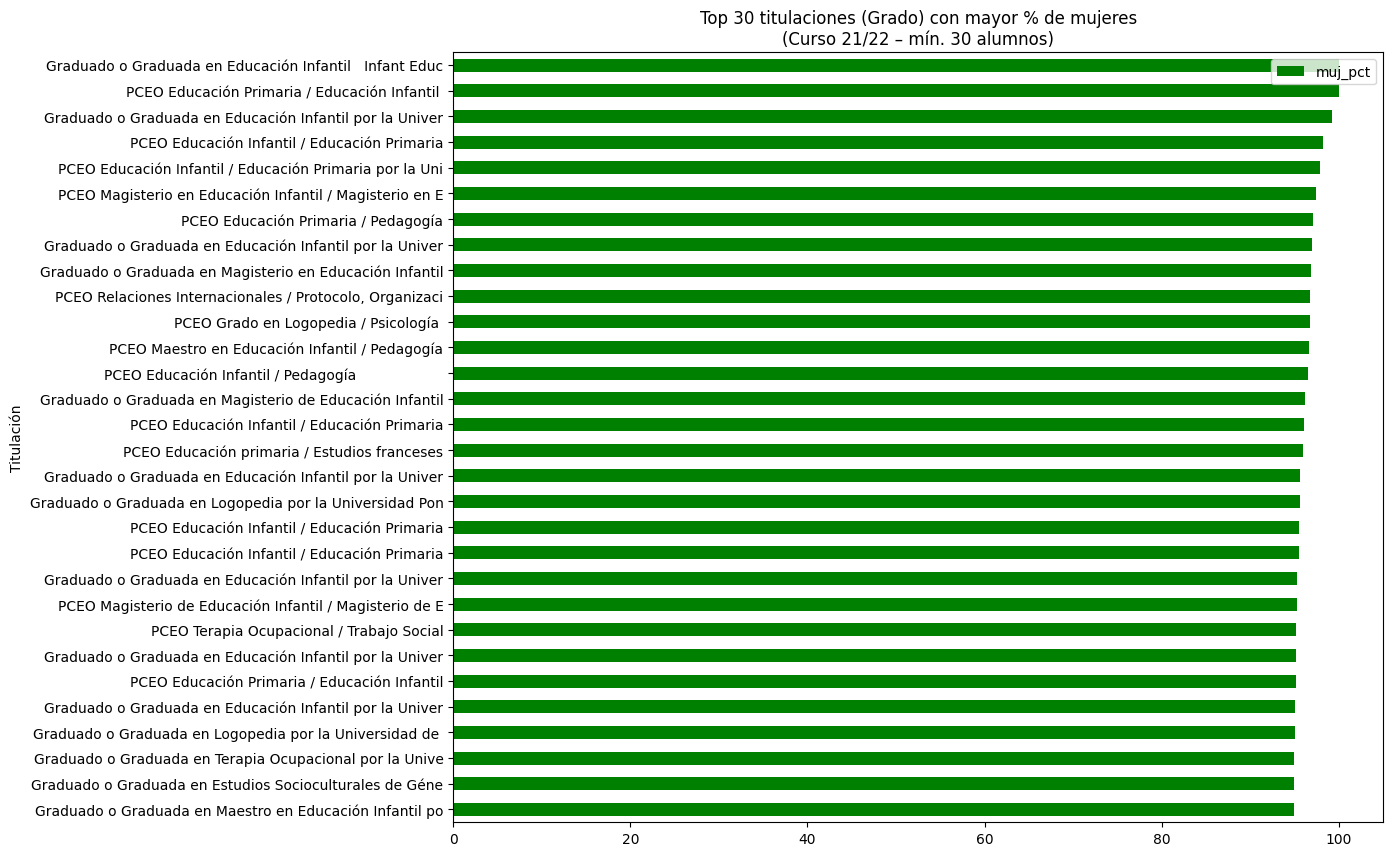

In [31]:
def top30_mujeres(df, nombre, color):
    # 1. Filtramos los nulos, hasta este punto no hemos visto nada de esto. Si hacen otro tratamiento (media, mediana) por mi OK
    df_m = df.dropna(subset=['mujeres2122', 'matriculas2122']).copy()

    # 2. Filtramos titulaciones con al menos 30 alumnos para que el % sea representativo / Si no hacen esto no pasa nada
    df_m = df_m[df_m['matriculas2122'] >= 30]

    # 3. Calculamos el porcentaje sobre 100
    df_m['muj_pct'] = df_m['mujeres2122'] * 100

    # 4. Sacamos las 30 con mayor porcentaje y ordenamos de menor a mayor
    top30 = df_m.nlargest(30, 'muj_pct').sort_values(by='muj_pct', ascending=True)

    # 5. Ponemos la Titulación como índice para que Pandas la use en las etiquetas del gráfico
    top30.set_index('Titulación', inplace=True)

    # Acorto titulos que se ve mal el gráfico si no
    top30.index = top30.index.str.replace('Máster Universitario en ', '').str.replace('Máster en ', '').str.replace('Grado en ', '').str[:55]

    # 6. El "atajo" de Pandas: dibujamos directamente
    grafico = top30['muj_pct'].plot.barh(
        title=f'Top 30 titulaciones ({nombre}) con mayor % de mujeres\n(Curso 21/22 – mín. 30 alumnos)',
        color=color,
        figsize=(12, 10)
    )

    grafico.legend()

    return top30

# Ejecutamos las funciones
top30_muj_grado  = top30_mujeres(df_grado,  'Grado',  'green')

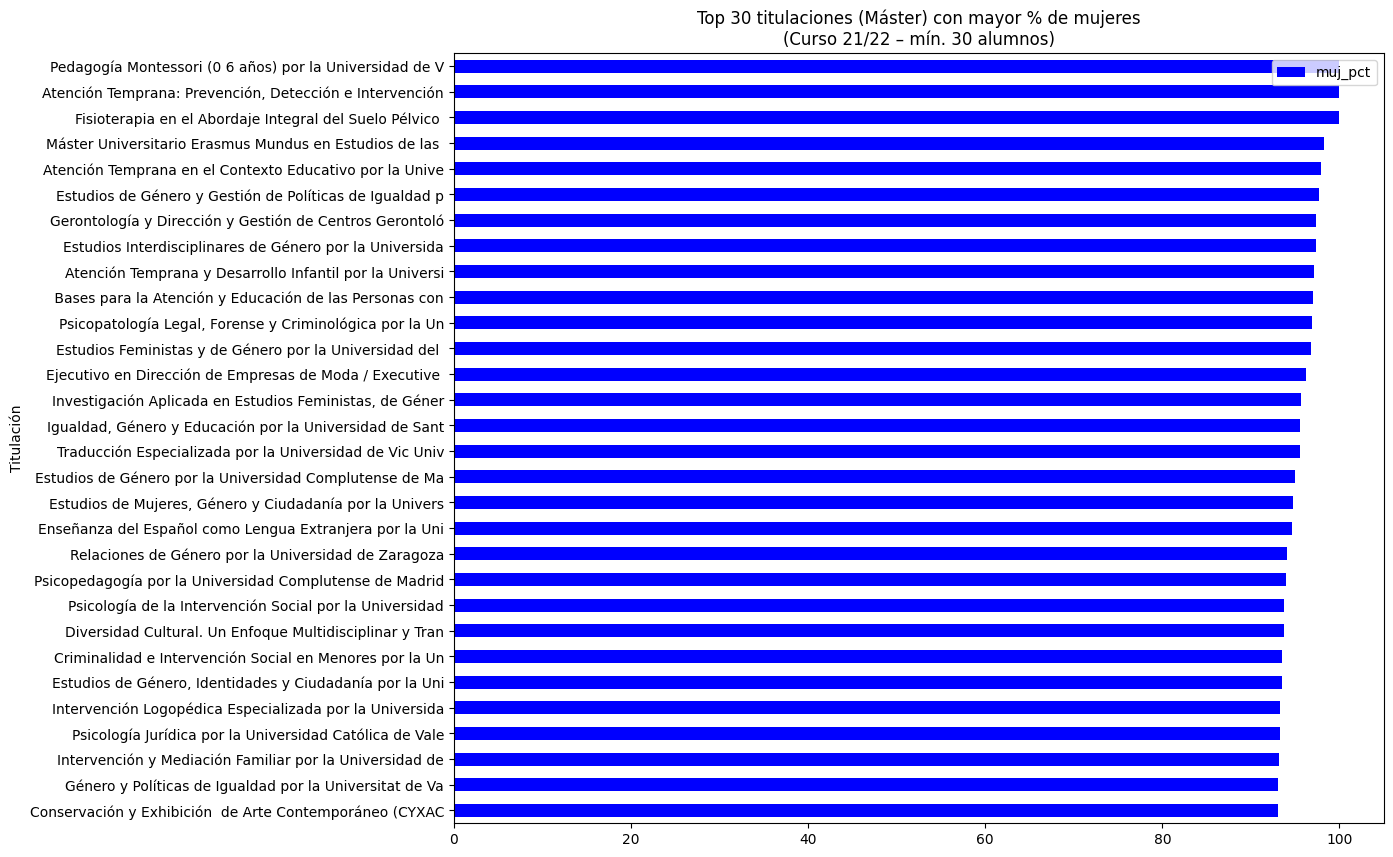

In [32]:
top30_muj_master = top30_mujeres(df_master, 'Máster', 'blue')

Evolución del % de mujeres por Rama de Conocimiento (7 cursos)


=== Grado: % real de mujeres por Rama y Curso ===
Rama  Artes y Humanidades  Ciencias  Ciencias Sociales y Jurídicas  Ciencias de la Salud  Ingeniería y Arquitectura
1516                61.15     51.07                          59.74                 69.40                      24.72
1617                61.42     51.05                          59.66                 69.56                      24.85
1718                61.59     51.06                          59.81                 70.02                      24.94
1819                61.67     51.05                          59.81                 70.36                      24.78
1920                61.90     50.81                          60.21                 70.91                      25.17
2021                62.32     50.73                          60.46                 71.47                      25.63
2122                62.69     50.78                          60.60                 71.76                      26.47

=== Máster: % real d

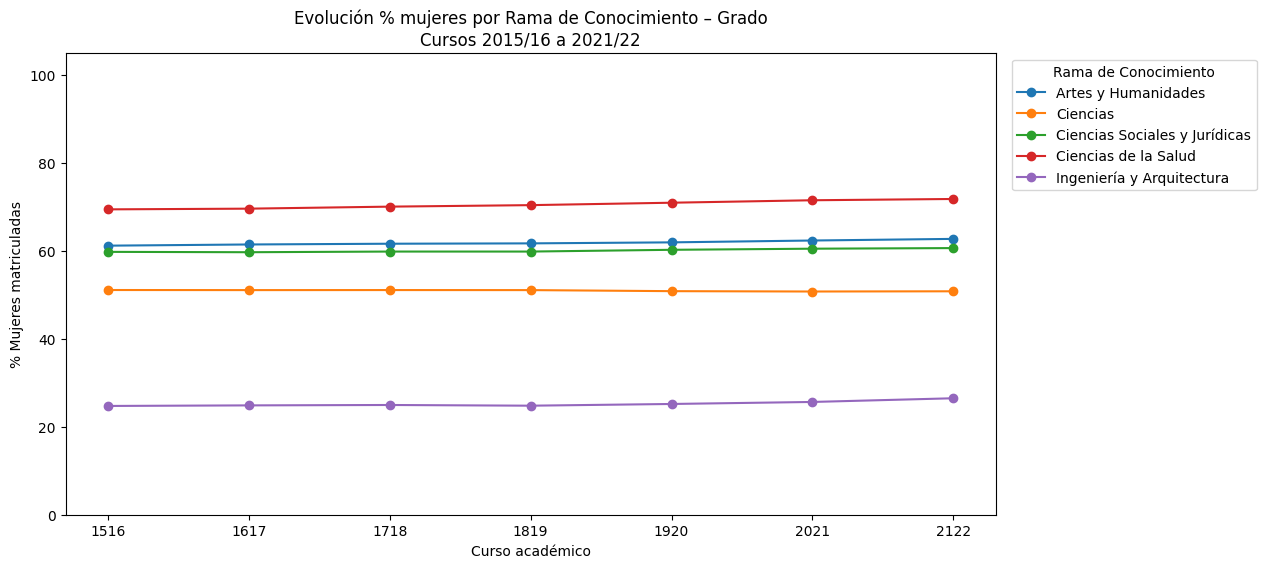

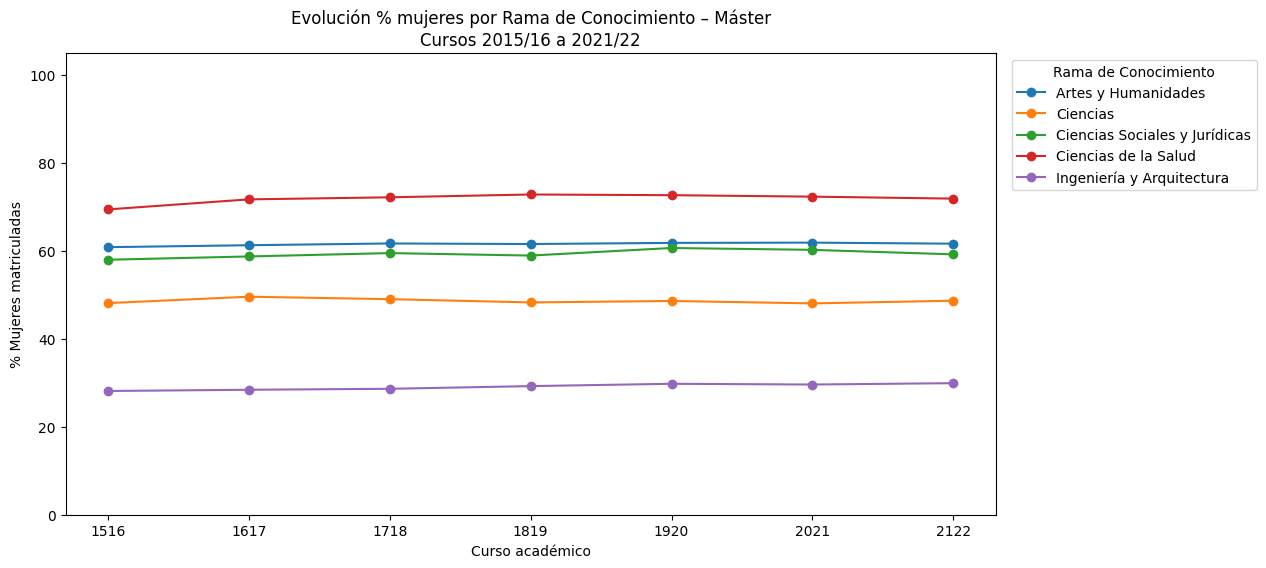

In [33]:
def evolucion_mujeres_rama(df, nombre):
    df_calc = df.copy()

    cursos = ['1516', '1617', '1718', '1819', '1920', '2021', '2122']

    # 2. Número de mujeres fisicas en cada titulación
    for c in cursos:
        # Como 'mujeres' ya viene como decimal (ej. 0.61), multiplicamos directamente
        df_calc[f'muj_abs_{c}'] = df_calc[f'matriculas{c}'] * df_calc[f'mujeres{c}']

    # Agrupamos por Rama y SUMAMOS (no hacemos la media)
    agrupado = df_calc.groupby('Rama').sum()

    # 3. Recalculamos el porcentaje real ponderado para cada curso
    evol_data = {}
    for c in cursos:
        # Aquí SÍ multiplicamos por 100 para pasarlo a formato visual (ej. de 0.61 a 61.0)
        evol_data[c] = (agrupado[f'muj_abs_{c}'] / agrupado[f'matriculas{c}']) * 100

    # 4. Creamos la tabla final y la transponemos (filas = cursos, columnas = ramas)
    evol_T = pd.DataFrame(evol_data).T.round(2)

    # 5. EL "ATAJO VISUAL" DE PANDAS
    grafico = evol_T.plot(
        kind='line',
        marker='o',
        figsize=(12, 6),
        ylim=(0, 105),
        title=f'Evolución % mujeres por Rama de Conocimiento – {nombre}\nCursos 2015/16 a 2021/22'
    )

    grafico.legend(title='Rama de Conocimiento', bbox_to_anchor=(1.01, 1), loc='upper left')
    grafico.set_ylabel('% Mujeres matriculadas')
    grafico.set_xlabel('Curso académico')

    print(f'\n=== {nombre}: % real de mujeres por Rama y Curso ===')
    print(evol_T.to_string())

    return evol_T

# Ejecutamos las funciones
evol_grado  = evolucion_mujeres_rama(df_grado,  'Grado')
evol_master = evolucion_mujeres_rama(df_master, 'Máster')

**Top 30 titulaciones con mayor presencia de mujeres:**
- Las titulaciones con mayor porcentaje de mujeres en grado pertenecen mayoritariamente a ramas de **Ciencias de la Salud** (Enfermería, Logopedia, Terapia Ocupacional) y **Artes y Humanidades** (Educación Infantil, Trabajo Social).
- En máster, el patrón es similar: posgrados vinculados a Salud y Ciencias Sociales presentan los porcentajes más altos.
- Para la campaña de marketing, el grupo educativo puede segmentar mejor: estas titulaciones tienen audiencia femenina consolidada.

**Evolución por Rama de Conocimiento (7 cursos):**
- Los porcentajes por rama son **notablemente estables** a lo largo de los 7 cursos analizados, sin cambios bruscos.
- **Ciencias de la Salud** mantiene el liderazgo femenino (aproximadamente 68-69% en grado), seguida de **Artes y Humanidades** (aproximadamente 63-65%).
- **Ingeniería y Arquitectura** presenta sistemáticamente los valores más bajos (~28-30%), aunque se observa una **tendencia ligeramente creciente** desde 2015/16 (27,6%) hasta 2021/22 (30,0%), lo que indica un avance gradual de la presencia femenina en estas carreras técnicas.
- **Ciencias Sociales y Jurídicas** se mantiene en torno al 60%, la rama objetivo del nuevo máster de Business Analytics del grupo educativo.

**5.Como reflexión final, ¿son estos datos útiles para la toma de decisiones del grupo educativo? Justifica brevemente tu respuesta.**

Sí, este dataset es **altamente útil** para la toma de decisiones estratégicas del grupo educativo, por las siguientes razones:

**1. Cobertura temporal y robustez:** Con datos de **7 cursos académicos consecutivos** (2015/16 a 2021/22), el dataset permite identificar tendencias sostenidas en el tiempo, no simples anomalías puntuales. Esto es clave para decisiones de inversión a largo plazo como la apertura de una nueva universidad.

**2. Granularidad adecuada:** El nivel de detalle (titulación × universidad × rama × comunidad autónoma) permite análisis competitivos muy precisos. El grupo educativo puede identificar en qué regiones, ramas y tipologías de titulación hay oportunidades de mercado sin cobertura suficiente.

**3. Validación del nicho objetivo:** El análisis de la pregunta 3 confirma que los másteres de Business Analytics en Ciencias Sociales y Jurídicas son un segmento con demanda real y consolidada, y que el número de mujeres en estos programas es bajo, lo que abre oportunidades de diferenciación en la captación.

**4. Información para la estrategia de marketing:** El análisis de la pregunta 4 permite identificar los perfiles de género por rama y titulación, lo que permite diseñar campañas de comunicación más efectivas y segmentadas.

**Limitación principal:** Los datos del Ministerio no incluyen información sobre **tasas de empleabilidad, ingresos post-graduación ni satisfacción del estudiante**, variables que también influirían en la decisión estratégica. Asimismo, los datos más recientes son de 2021/22, por lo que habría que complementar el análisis con información más actualizada para capturar el impacto post-pandemia en las matriculaciones.

En conclusión, este dataset es una **base sólida y rigurosa** para el proyecto de Inteligencia de Negocio, y su análisis aporta evidencia objetiva para orientar decisiones de alto impacto económico.